Read data from .root file

In [1]:
import uproot 
import hist
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import itertools
import numpy as np
import pandas as pd

# Open the ROOT file and read the TTree
with uproot.open("./Outputs/L1PCA_7Li.root") as file:
    tree_RAW = file["L1PCA"].arrays(library="pd")





In [2]:
tree_RAW.describe()

,fQave,fLight_fQtotal,fThetaLight,fLight_fTL,fLight_fRawTL,fPhiLight,chargePerVoxelLight,qRatio,lastThirdQ,nVoxelsLight,zDrift
count,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000
mean,1139.898071,62489.792969,79.379478,69.935265,27.429508,-6.828113,1046.319092,5.038981,39923.175781,64.882032,111.802910
std,259.177460,26137.443359,14.550879,35.027767,15.704028,95.953911,214.661194,15.889116,13118.236328,36.438700,47.429070
min,600.168396,7869.000000,5.567853,6.858390,4.142540,-178.300842,445.717163,-1.000000,-1.000000,15.000000,-5.107178
25%,945.816513,42248.500000,77.678690,41.481181,14.856227,-92.751274,892.494232,2.596933,29870.000000,37.000000,82.681967
50%,1120.062744,59258.000000,79.495930,62.935181,23.956341,-29.817823,1033.757324,3.226612,38440.000000,56.000000,109.849083
75%,1321.181854,79580.750000,81.347050,93.001791,37.362456,82.691156,1179.460297,4.524330,48475.750000,86.000000,139.131260
max,3492.918945,621177.000000,179.673141,267.095001,126.267311,176.177902,2269.250000,753.028992,275234.000000,422.000000,252.491867


Remove all the NaNs in the tree

In [3]:
print('Check for NaN values in normalized numeric columns:')
numeric_cols = tree_RAW.select_dtypes(include=[np.number]).columns
nan_counts = tree_RAW[numeric_cols].isna().sum()
print(nan_counts)
#Remove nans
tree = tree_RAW.dropna(subset=numeric_cols)
print('After dropping NaN values, check for NaN again:')
print(tree[numeric_cols].isna().sum())

Check for NaN values in normalized numeric columns:
fQave                  0
fLight_fQtotal         0
fThetaLight            0
fLight_fTL             0
fLight_fRawTL          0
fPhiLight              0
chargePerVoxelLight    0
qRatio                 0
lastThirdQ             0
nVoxelsLight           0
zDrift                 0
dtype: int64
After dropping NaN values, check for NaN again:
fQave                  0
fLight_fQtotal         0
fThetaLight            0
fLight_fTL             0
fLight_fRawTL          0
fPhiLight              0
chargePerVoxelLight    0
qRatio                 0
lastThirdQ             0
nVoxelsLight           0
zDrift                 0
dtype: int64


In [4]:
#Add sin and cosin of phi and theta
tree["fSinPhi"]=np.sin(tree["fPhiLight"])
tree["fCosPhi"]=np.cos(tree["fPhiLight"])
tree["fSinTheta"]=np.sin(tree["fThetaLight"])
tree["fCosTheta"]=np.cos(tree["fThetaLight"])

In [5]:
# Get all the variables squared
tree["fQave2"] = tree["fQave"] ** 2
tree["fQtotal2"] = tree["fLight_fQtotal"] ** 2
tree["fThetaLight2"] = tree["fThetaLight"] ** 2
tree["fTL2"] = tree["fLight_fTL"] ** 2
tree["fRawTL2"] = tree["fLight_fRawTL"] ** 2
tree["fPhiLight2"] = tree["fPhiLight"] ** 2
tree["chargePerVoxelLight2"] = tree["chargePerVoxelLight"] ** 2
tree["qRatio2"] = tree["qRatio"] ** 2
tree["lastThirdQ2"] = tree["lastThirdQ"] ** 2
tree["nVoxelsLight2"] = tree["nVoxelsLight"] ** 2
tree["zDrift2"] = tree["zDrift"] ** 2

tree["fCosPhi2"] = tree["fCosPhi"] ** 2
tree["fSinPhi2"] = tree["fSinPhi"] ** 2
tree["fCosTheta2"] = tree["fCosTheta"] ** 2
tree["fSinTheta2"] = tree["fSinTheta"] ** 2

In [6]:
#Get all the variables cubed
tree["fQave3"] = tree["fQave"] ** 3
tree["fQtotal3"] = tree["fLight_fQtotal"] ** 3
tree["fThetaLight3"] = tree["fThetaLight"] ** 3
tree["fTL3"] = tree["fLight_fTL"] ** 3
tree["fRawTL3"] = tree["fLight_fRawTL"] ** 3
tree["fPhiLight3"] = tree["fPhiLight"] ** 3
tree["chargePerVoxelLight3"] = tree["chargePerVoxelLight"] ** 3
tree["qRatio3"] = tree["qRatio"] ** 3
tree["lastThirdQ3"] = tree["lastThirdQ"] ** 3
tree["nVoxelsLight3"] = tree["nVoxelsLight"] ** 3
tree["zDrift3"] = tree["zDrift"] ** 3

tree["fCosPhi3"] = tree["fCosPhi"] ** 3
tree["fSinPhi3"] = tree["fSinPhi"] ** 3
tree["fCosTheta3"] = tree["fCosTheta"] ** 3
tree["fSinTheta3"] = tree["fSinTheta"] ** 3

In [7]:
# Get all the variables multiplied by each other
# Multiplication is commutative, so we generate each unordered pair once.

mul_vars = [
    "fQave", "fLight_fQtotal", "fThetaLight", "fLight_fTL", "fLight_fRawTL",
    "fPhiLight", "chargePerVoxelLight", "qRatio", "lastThirdQ", "nVoxelsLight",
    "zDrift", "fSinPhi", "fCosPhi", "fSinTheta", "fCosTheta",
]

for a, b in itertools.combinations(mul_vars, 2):
    tree[f"{a}_{b}"] = tree[a] * tree[b]

# Get all the variables divided by each other
# Division is not commutative, so we generate both ordered directions.
div_vars = [
    "fQave", "fLight_fQtotal", "fThetaLight", "fLight_fTL", "fLight_fRawTL",
    "fPhiLight", "chargePerVoxelLight", "qRatio", "lastThirdQ", "nVoxelsLight",
    "zDrift", "fSinPhi", "fCosPhi", "fSinTheta", "fCosTheta",
]

for numerator in div_vars:
    for denominator in div_vars:
        if numerator == denominator:
            continue
        column_name = f"{numerator}_{denominator}_div"
        tree[column_name] = tree[numerator] / tree[denominator]

/tmp/ipykernel_76187/2280885520.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tree[f"{a}_{b}"] = tree[a] * tree[b]
/tmp/ipykernel_76187/2280885520.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tree[f"{a}_{b}"] = tree[a] * tree[b]
/tmp/ipykernel_76187/2280885520.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use 

/tmp/ipykernel_76187/2280885520.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tree[column_name] = tree[numerator] / tree[denominator]
/tmp/ipykernel_76187/2280885520.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tree[column_name] = tree[numerator] / tree[denominator]
/tmp/ipykernel_76187/2280885520.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inste

In [8]:
#Add Charge / cosTheta
tree["fChargeOverCosTheta"]=tree["fLight_fQtotal"]/np.cos(tree["fThetaLight"])

/tmp/ipykernel_76187/981613741.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tree["fChargeOverCosTheta"]=tree["fLight_fQtotal"]/np.cos(tree["fThetaLight"])


DO THE PCA

In [9]:

# select numeric columns only
num_cols = tree.select_dtypes(include=["number"]).columns
# compute population standard deviation (ddof=0) and avoid zeros
stds = tree[num_cols].std(ddof=0)
stds = stds.replace(0, 1.0)
# create normalized copy
df_norm = tree.copy()
df_norm[num_cols] = tree[num_cols] / stds
print('Normalized numeric columns by std (ddof=0):')
print(stds)
# inspect first rows
print(df_norm.head())

/home/ivan/actar_env/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/ivan/actar_env/lib/python3.12/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Normalized numeric columns by std (ddof=0):
fQave                      2.591749e+02
fLight_fQtotal             2.613718e+04
fThetaLight                1.455073e+01
fLight_fTL                 3.502742e+01
fLight_fRawTL              1.570387e+01
                               ...     
fCosTheta_zDrift_div       3.440794e-01
fCosTheta_fSinPhi_div      8.790401e+01
fCosTheta_fCosPhi_div      1.001324e+02
fCosTheta_fSinTheta_div    9.764642e+01
fChargeOverCosTheta        1.822717e+07
Length: 361, dtype: float64
      fQave  fLight_fQtotal  fThetaLight  fLight_fTL  fLight_fRawTL  \
0  4.630866        3.116097     5.351329    2.159608       2.161061   
1  5.835769        2.612102     5.511370    1.481635       1.435951   
2  5.794056        1.542324     5.819591    1.090965       0.751847   
3  4.823833        2.337513     5.509252    1.579979       1.425311   
4  3.756209        3.931564     5.271179    3.259957       2.852005   

   fPhiLight  chargePerVoxelLight    qRatio  lastThirdQ  nVox

In [10]:
df_norm.describe()

,fQave,fLight_fQtotal,fThetaLight,fLight_fTL,fLight_fRawTL,fPhiLight,chargePerVoxelLight,qRatio,lastThirdQ,nVoxelsLight,...,fCosTheta_fPhiLight_div,fCosTheta_chargePerVoxelLight_div,fCosTheta_qRatio_div,fCosTheta_lastThirdQ_div,fCosTheta_nVoxelsLight_div,fCosTheta_zDrift_div,fCosTheta_fSinPhi_div,fCosTheta_fCosPhi_div,fCosTheta_fSinTheta_div,fChargeOverCosTheta
count,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,...,50378.000000,50378.000000,0.0,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000
mean,4.398181,2.390839,5.455359,1.996586,1.746672,-0.071161,4.874330,0.317137,3.043364,1.780598,...,-0.004474,-0.080074,NaN,0.008582,0.015703,0.000569,0.007036,-0.003214,-0.003932,-0.003867
std,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,...,1.000010,1.000010,NaN,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010
min,2.315689,0.301065,0.382651,0.195801,0.263791,-1.858211,2.076396,-0.062937,-0.000076,0.411654,...,-224.450390,-2.730020,NaN,-65.997908,-3.905102,-38.777003,-72.500445,-192.735193,-122.306467,-171.621172
25%,3.649337,1.616414,5.338472,1.184249,0.946023,-0.966633,4.157729,0.163443,2.277005,1.015414,...,-0.001501,-0.973363,NaN,-0.001171,-0.622303,-0.018330,-0.011377,-0.009967,-0.010372,-0.005522
50%,4.321648,2.267191,5.463362,1.796740,1.525505,-0.310755,4.815810,0.203073,2.930301,1.536843,...,-0.000048,-0.134882,NaN,-0.000169,-0.089877,-0.002662,0.000107,0.000123,-0.000148,-0.002180
75%,5.097646,3.044733,5.590580,2.655114,2.379187,0.861789,5.494575,0.284747,3.695331,2.360152,...,0.001472,0.843674,NaN,0.001099,0.612369,0.016268,0.011367,0.009997,0.010015,0.004498
max,13.477073,23.766027,12.348046,7.625312,8.040521,1.836086,10.571414,47.393227,20.981229,11.581209,...,0.750460,2.715809,NaN,67.673997,3.918799,143.376999,165.625160,48.785175,74.366274,44.920475


Check again for NaNs

In [11]:
# =========================
# 1. NaNs por columna
# =========================
nan_counts = df_norm[num_cols].isna().sum()

print("NaN per column:")
print(nan_counts[nan_counts > 0].sort_values(ascending=False))

# =========================
# 2. filas que tienen al menos un NaN
# =========================
rows_with_nan = df_norm[num_cols].isna().any(axis=1)

print("\nNumber of rows with at least one NaN:")
print(rows_with_nan.sum())

print("Total rows before dropna:")
print(len(df_norm))

# =========================
# 3. ver proporción
# =========================
print("\nFraction of affected rows:")
print(rows_with_nan.mean())

NaN per column:
fQave_qRatio_div                  50378
fLight_fQtotal_qRatio_div         50378
fThetaLight_qRatio_div            50378
fLight_fTL_qRatio_div             50378
fLight_fRawTL_qRatio_div          50378
fPhiLight_qRatio_div              50378
chargePerVoxelLight_qRatio_div    50378
lastThirdQ_qRatio_div             50378
nVoxelsLight_qRatio_div           50378
zDrift_qRatio_div                 50378
fSinPhi_qRatio_div                50378
fCosPhi_qRatio_div                50378
fSinTheta_qRatio_div              50378
fCosTheta_qRatio_div              50378
dtype: int64

Number of rows with at least one NaN:
50378
Total rows before dropna:
50378

Fraction of affected rows:
1.0


Text(0.5, 1.0, 'Distribution of qRatio')

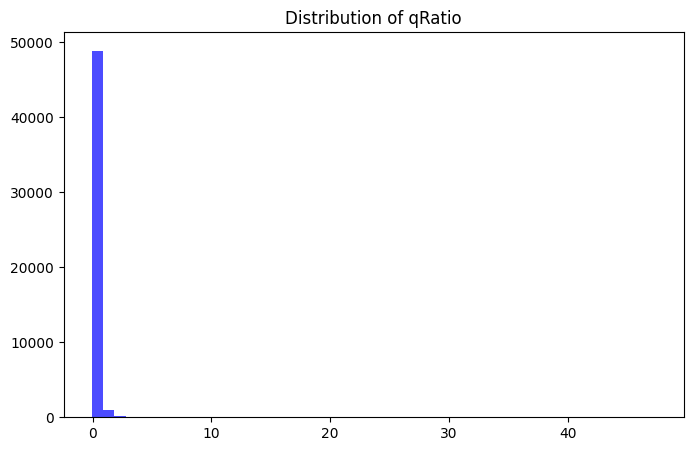

In [ ]:
#plot 1d of qratio
plt.figure(figsize=(8, 5))
plt.hist(df_norm["qRatio"], bins=10000, color="blue", alpha=0.7)
plt.title("Distribution of qRatio")

In [11]:
print('Check for NaN values in normalized numeric columns:')
print(df_norm[num_cols].isna().sum())
# Remove the rows with NaN values in the numeric columns
df_norm = df_norm.dropna(subset=num_cols)
print('After dropping NaN values, check for NaN again:')
print(df_norm[num_cols].isna().sum())

Check for NaN values in normalized numeric columns:
fQave                      0
fLight_fQtotal             0
fThetaLight                0
fLight_fTL                 0
fLight_fRawTL              0
                          ..
fCosTheta_zDrift_div       0
fCosTheta_fSinPhi_div      0
fCosTheta_fCosPhi_div      0
fCosTheta_fSinTheta_div    0
fChargeOverCosTheta        0
Length: 361, dtype: int64
After dropping NaN values, check for NaN again:
fQave                      0
fLight_fQtotal             0
fThetaLight                0
fLight_fTL                 0
fLight_fRawTL              0
                          ..
fCosTheta_zDrift_div       0
fCosTheta_fSinPhi_div      0
fCosTheta_fCosPhi_div      0
fCosTheta_fSinTheta_div    0
fChargeOverCosTheta        0
Length: 361, dtype: int64


In [11]:
df_norm.describe()

,fQave,fLight_fQtotal,fThetaLight,fLight_fTL,fLight_fRawTL,fPhiLight,chargePerVoxelLight,qRatio,lastThirdQ,nVoxelsLight,...,fCosTheta_fPhiLight_div,fCosTheta_chargePerVoxelLight_div,fCosTheta_qRatio_div,fCosTheta_lastThirdQ_div,fCosTheta_nVoxelsLight_div,fCosTheta_zDrift_div,fCosTheta_fSinPhi_div,fCosTheta_fCosPhi_div,fCosTheta_fSinTheta_div,fChargeOverCosTheta
count,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,...,50378.000000,50378.000000,0.0,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000,50378.000000
mean,4.398181,2.390839,5.455359,1.996586,1.746672,-0.071161,4.874330,0.317137,3.043364,1.780598,...,-0.004474,-0.080074,NaN,0.008582,0.015703,0.000569,0.007036,-0.003214,-0.003932,-0.003867
std,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,...,1.000010,1.000010,NaN,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010,1.000010
min,2.315689,0.301065,0.382651,0.195801,0.263791,-1.858211,2.076396,-0.062937,-0.000076,0.411654,...,-224.450390,-2.730020,NaN,-65.997908,-3.905102,-38.777003,-72.500445,-192.735193,-122.306467,-171.621172
25%,3.649337,1.616414,5.338472,1.184249,0.946023,-0.966633,4.157729,0.163443,2.277005,1.015414,...,-0.001501,-0.973363,NaN,-0.001171,-0.622303,-0.018330,-0.011377,-0.009967,-0.010372,-0.005522
50%,4.321648,2.267191,5.463362,1.796740,1.525505,-0.310755,4.815810,0.203073,2.930301,1.536843,...,-0.000048,-0.134882,NaN,-0.000169,-0.089877,-0.002662,0.000107,0.000123,-0.000148,-0.002180
75%,5.097646,3.044733,5.590580,2.655114,2.379187,0.861789,5.494575,0.284747,3.695331,2.360152,...,0.001472,0.843674,NaN,0.001099,0.612369,0.016268,0.011367,0.009997,0.010015,0.004498
max,13.477073,23.766027,12.348046,7.625312,8.040521,1.836086,10.571414,47.393227,20.981229,11.581209,...,0.750460,2.715809,NaN,67.673997,3.918799,143.376999,165.625160,48.785175,74.366274,44.920475


In [12]:
pca=PCA(n_components=5)
pca.fit(df_norm[num_cols])
print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Principal components:\n', pca.components_)


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

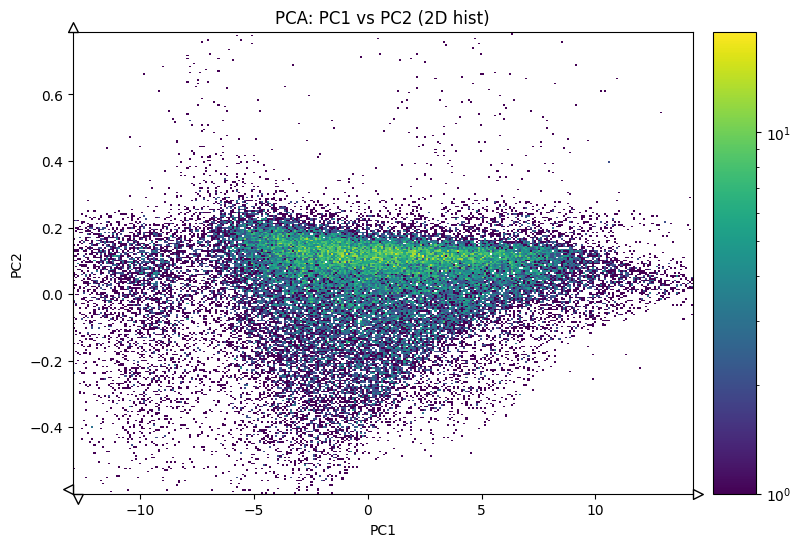

In [15]:
# 2D histogram of the first two PCA components using `hist`
pca_result = pca.transform(df_norm[num_cols])
pc1 = pca_result[:, 0]
pc2 = pca_result[:, 1]
# use robust percentile-driven ranges to avoid extreme outliers
xmin, xmax = np.percentile(pc1, [0.5, 99.5])
ymin, ymax = np.percentile(pc2, [0.5, 99.5])
# build a 2D hist with the `hist` package
h2 = hist.Hist(hist.axis.Regular(300, xmin, xmax, name="PC1"),
               hist.axis.Regular(300, ymin, ymax, name="PC2"))
h2.fill(PC1=pc1, PC2=pc2)
# draw with matplotlib (use pcolormesh from the histogram edges and values)
fig, ax = plt.subplots(figsize=(8,6))
h2.plot(ax=ax,norm=mcolors.LogNorm(), cmap='viridis')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA: PC1 vs PC2 (2D hist)')
plt.show()

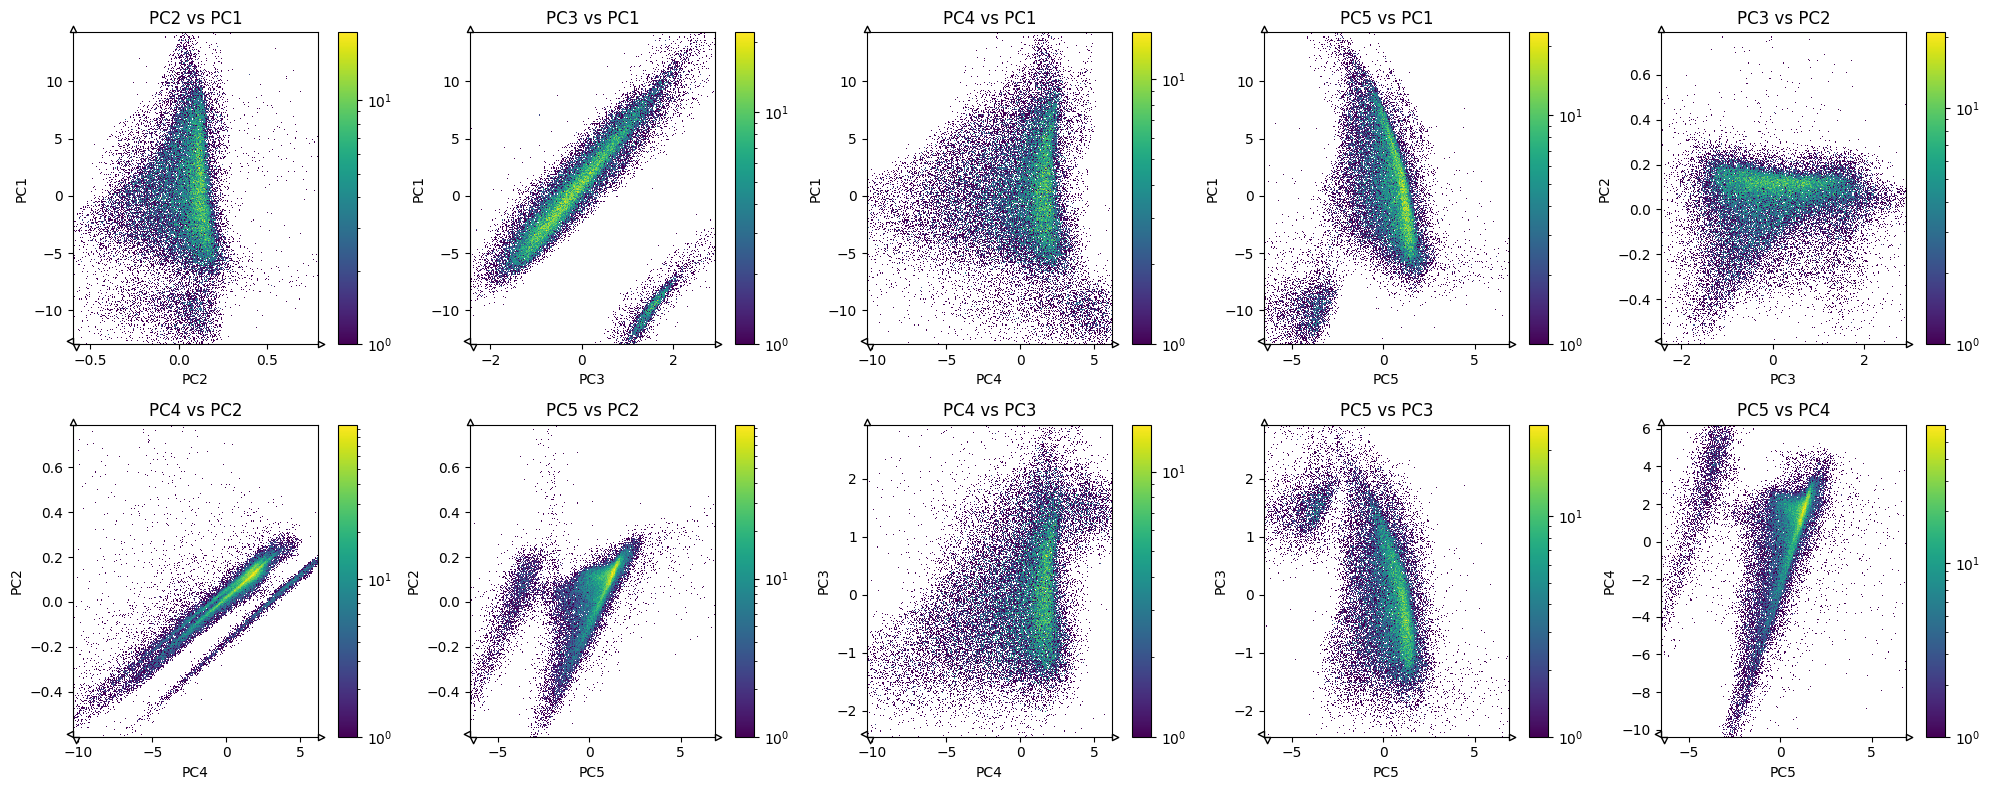

In [17]:
# PCA transform
pca_result = pca.transform(df_norm[num_cols])

n_comp = 5
pairs = list(itertools.combinations(range(n_comp), 2))

# layout (2 filas x 5 columnas = 10 plots)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, (i, j) in zip(axes.flatten(), pairs):
    
    pcx = pca_result[:, j]
    pcy = pca_result[:, i]
    
    # percentiles robustos
    xmin, xmax = np.percentile(pcx, [0.5, 99.5])
    ymin, ymax = np.percentile(pcy, [0.5, 99.5])
    
    # histograma 2D
    h2 = hist.Hist(
        hist.axis.Regular(300, xmin, xmax, name=f"PC{j+1}"),
        hist.axis.Regular(300, ymin, ymax, name=f"PC{i+1}")
    )
    
    h2.fill(**{f"PC{j+1}": pcx, f"PC{i+1}": pcy})
    
    # plot
    h2.plot(ax=ax, norm=mcolors.LogNorm(), cmap='viridis')
    
    ax.set_xlabel(f'PC{j+1}')
    ax.set_ylabel(f'PC{i+1}')
    ax.set_title(f'PC{j+1} vs PC{i+1}')

plt.tight_layout()
plt.show()

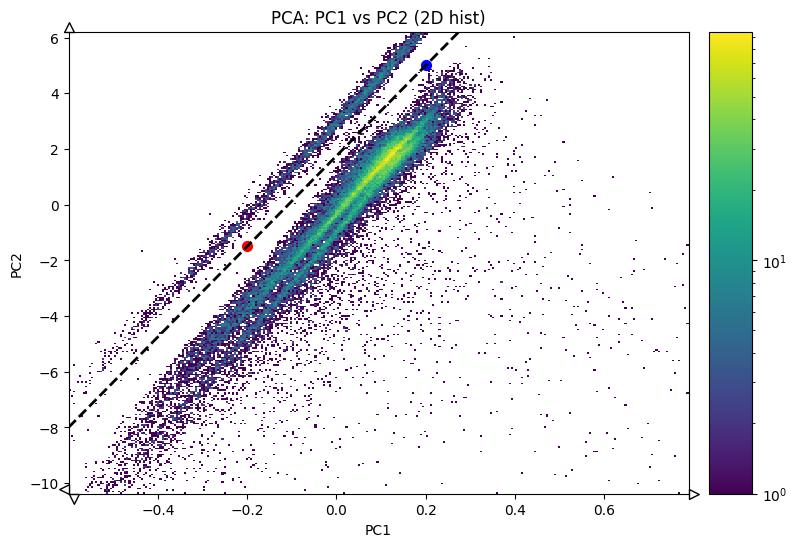

In [26]:
# 2D histogram of the two best PCA components using `hist`
pca_result = pca.transform(df_norm[num_cols])
pc1 = pca_result[:, 1]
pc2 = pca_result[:, 3]
# use robust percentile-driven ranges to avoid extreme outliers
xmin, xmax = np.percentile(pc1, [0.5, 99.5])
ymin, ymax = np.percentile(pc2, [0.5, 99.5])
# build a 2D hist with the `hist` package
h2 = hist.Hist(hist.axis.Regular(300, xmin, xmax, name="PC1"),
               hist.axis.Regular(300, ymin, ymax, name="PC2"))
h2.fill(PC1=pc1, PC2=pc2)
# draw with matplotlib (use pcolormesh from the histogram edges and values)
fig, ax = plt.subplots(figsize=(8,6))
h2.plot(ax=ax,norm=mcolors.LogNorm(), cmap='viridis')

# 🔴 puntos
p1 = (-0.2, -1.5)
p2 = (0.2, 5)

ax.scatter(*p1, color='red', s=50, label='Point 1')
ax.scatter(*p2, color='blue', s=50, label='Point 2')


# calcular recta
x1, y1 = p1
x2, y2 = p2

m = (y2 - y1) / (x2 - x1)
b = y1 - m * x1

# extender al rango del histograma
x_line = np.linspace(xmin, xmax, 500)
y_line = m * x_line + b

ax.plot(x_line, y_line, color='black', linewidth=2, linestyle='--')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA: PC1 vs PC2 (2D hist)')
plt.show()

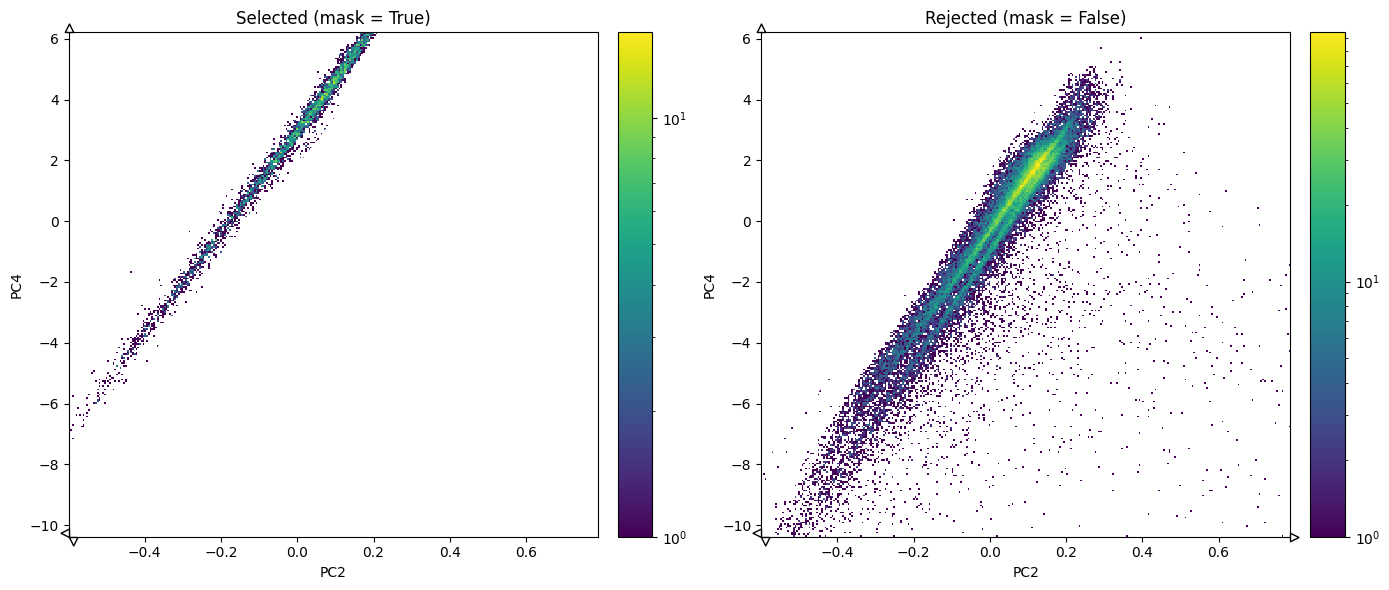

Selected: (4607, 107)
Rejected: (45761, 107)


In [30]:
# =========================
# PCA components
# =========================
pc1 = pca_result[:, 1]  # PC2
pc2 = pca_result[:, 3]  # PC4

# =========================
# recta definida por 2 puntos
# =========================
p1 = (-0.2, -1.5)
p2 = (0.2, 5)

x1, y1 = p1
x2, y2 = p2

dx = x2 - x1
dy = y2 - y1

mask = (pc1 - x1)*dy - (pc2 - y1)*dx < 0

# invertir si hace falta
# mask = ~mask

# =========================
# rangos comunes (importante)
# =========================
xmin, xmax = np.percentile(pc1, [0.5, 99.5])
ymin, ymax = np.percentile(pc2, [0.5, 99.5])

# =========================
# histogramas separados
# =========================
h_sel = hist.Hist(
    hist.axis.Regular(300, xmin, xmax, name="PC1"),
    hist.axis.Regular(300, ymin, ymax, name="PC2")
)

h_bkg = hist.Hist(
    hist.axis.Regular(300, xmin, xmax, name="PC1"),
    hist.axis.Regular(300, ymin, ymax, name="PC2")
)

h_sel.fill(PC1=pc1[mask], PC2=pc2[mask])
h_bkg.fill(PC1=pc1[~mask], PC2=pc2[~mask])

# =========================
# plot
# =========================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- seleccionados ---
h_sel.plot(ax=ax[0], norm=mcolors.LogNorm(), cmap='viridis')
ax[0].set_title('Selected (mask = True)')
ax[0].set_xlabel('PC2')
ax[0].set_ylabel('PC4')

# recta encima
x_line = np.linspace(xmin, xmax, 500)
if dx != 0:
    m = dy / dx
    b = y1 - m * x1
    y_line = m * x_line + b
    ax[0].plot(x_line, y_line, 'w--', linewidth=2)
else:
    ax[0].axvline(x=x1, color='w', linestyle='--', linewidth=2)

# --- fondo ---
h_bkg.plot(ax=ax[1], norm=mcolors.LogNorm(), cmap='viridis')
ax[1].set_title('Rejected (mask = False)')
ax[1].set_xlabel('PC2')
ax[1].set_ylabel('PC4')

if dx != 0:
    ax[1].plot(x_line, y_line, 'w--', linewidth=2)
else:
    ax[1].axvline(x=x1, color='w', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

# =========================
# output data
# =========================
selected_data = df_norm[mask]
rejected_data = df_norm[~mask]

print("Selected:", selected_data.shape)
print("Rejected:", rejected_data.shape)

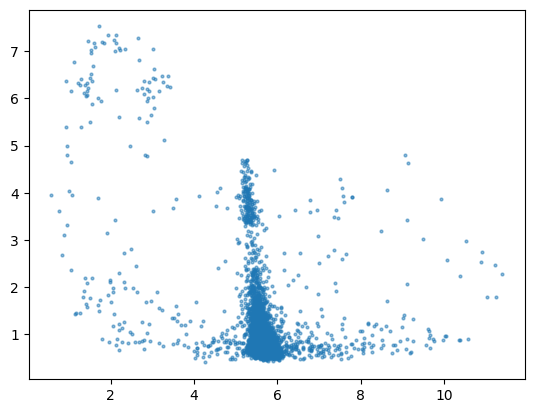

In [31]:
#Plot the kinematics (Theta vs TL) for the selected data
plt.plot(selected_data["fThetaLight"], selected_data["fLight_fTL"], 'o', markersize=2, alpha=0.5)